# ML - REGRESION LINEAL REGULARIZADA (EDA)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pickle
from sklearn.feature_selection import f_regression, SelectKBest

## Paso 1: Definicion del problema (target)
Decidimos que la variable obejtivo que vamos a predecir es `Heart disease_prevalence` ya que está relacionada con la salud y con varias variables predictoras

## Paso 2: Recopilacion de datos
[fuente](https://raw.githubusercontent.com/4GeeksAcademy/regularized-linear-regression-project-tutorial/main/demographic_health_data.csv)

### Importamos los datos y creamos el DataFrame

In [2]:
df = pd.read_csv('../data/raw/demographic_health_data.csv', index_col='COUNTY_NAME')
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Autauga,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
Baldwin,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
Barbour,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
Bibb,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
Blount,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


In [3]:
# Importamos los datos de la información de las variables
df_info_columns = pd.read_csv('/workspaces/pabloaznar-intro-ml/data/raw/data_dict.csv', index_col='Column')
df_info_columns

,description,info
Column,,
fips,FIPS Code for the County,NaN
TOT_POP,Total Population,This data as well as all Age and Race data is ...
0-9,Population aged 0-9,All of the other age columns are the same but ...
0-9 y/o % of total pop,% of the population aged 0-9,NaN
10-19',NaN,NaN
...,...,...
NaN,"7 (Urban population of 2,500 to 19,999, not ad...",NaN
NaN,"8 (Completely rural or less than 2,500 urban p...",NaN
NaN,"9 (Completely rural or less than 2,500 urban p...",NaN


## Paso 3: Realizamos un EDA completo

### Analisis descriptivo

In [4]:
# Obtenemos las dimensiones
df.shape

(3140, 107)

In [5]:
# Obtenemos informacion sobre el tipo de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3140 entries, Autauga to Weston
Columns: 107 entries, fips to Urban_rural_code
dtypes: float64(61), int64(45), object(1)
memory usage: 2.6+ MB


In [6]:
# Obtenemos información estadística de las variables numércias
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fips,3140.0,30401.640764,15150.559265,1001.0,18180.500000,29178.000000,45081.50000,5.604500e+04
TOT_POP,3140.0,104189.412420,333583.395432,88.0,10963.250000,25800.500000,67913.00000,1.010552e+07
0-9,3140.0,12740.302866,41807.301846,0.0,1280.500000,3057.000000,8097.00000,1.208253e+06
0-9 y/o % of total pop,3140.0,11.871051,2.124081,0.0,10.594639,11.802727,12.95184,2.546068e+01
19-Oct,3140.0,13367.976752,42284.392134,0.0,1374.500000,3274.000000,8822.25000,1.239139e+06
...,...,...,...,...,...,...,...,...
CKD_prevalence,3140.0,3.446242,0.568059,1.8,3.100000,3.400000,3.80000,6.200000e+00
CKD_Lower 95% CI,3140.0,3.207516,0.527740,1.7,2.900000,3.200000,3.50000,5.800000e+00
CKD_Upper 95% CI,3140.0,3.710478,0.613069,1.9,3.300000,3.700000,4.10000,6.600000e+00
CKD_number,3140.0,2466.234076,7730.422067,3.0,314.750000,718.000000,1776.25000,2.377660e+05


In [7]:
# Obtenemos información estadística del target
df['Heart disease_prevalence'].describe()

count    3140.000000
mean        8.607803
std         1.758587
min         3.500000
25%         7.400000
50%         8.600000
75%         9.800000
max        15.100000
Name: Heart disease_prevalence, dtype: float64

> ## Observaciones:
>
> - Existen un total de 3140 filas (en este caso, condados) y 107 columnas
> - Los datos constan de 106 variables numéricas y 1 categórica

### Limpieza de datos

In [8]:
# Comprobamos si hay valores duplicados
df[df.duplicated()]

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,


In [9]:
# Filtros para verificar las columnas redundantes que vamos a borrar
cols_a_borrar_pos = list(range(2, 32, 2))  # De la variable que esta en la posicion 2 a la 32 los totales se encuentran en las posiciones impares
cols_a_borrar = [df.columns[i] for i in cols_a_borrar_pos]

print("Columnas a borrar:", cols_a_borrar)

Columnas a borrar: ['0-9', '19-Oct', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+', 'White-alone pop', 'Black-alone pop', 'Native American/American Indian-alone pop', 'Asian-alone pop', 'Hawaiian/Pacific Islander-alone pop', 'Two or more races pop']


In [10]:
# Eliminamos las variables numericas con los totales/conteos y nos quedamos con la misma informacion pero en porcentajes para evitar redundancia
df = df.drop(columns=cols_a_borrar)
df.columns

Index(['fips', 'TOT_POP', '0-9 y/o % of total pop', '10-19 y/o % of total pop',
       '20-29 y/o % of total pop', '30-39 y/o % of total pop',
       '40-49 y/o % of total pop', '50-59 y/o % of total pop',
       '60-69 y/o % of total pop', '70-79 y/o % of total pop',
       '80+ y/o % of total pop', '% White-alone', '% Black-alone',
       '% NA/AI-alone', '% Asian-alone', '% Hawaiian/PI-alone',
       '% Two or more races', 'POP_ESTIMATE_2018', 'N_POP_CHG_2018',
       'GQ_ESTIMATES_2018', 'R_birth_2018', 'R_death_2018',
       'R_NATURAL_INC_2018', 'R_INTERNATIONAL_MIG_2018', 'R_DOMESTIC_MIG_2018',
       'R_NET_MIG_2018', 'Less than a high school diploma 2014-18',
       'High school diploma only 2014-18',
       'Some college or associate's degree 2014-18',
       'Bachelor's degree or higher 2014-18',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing som

In [11]:
# Otro filtro para borrar columnas redundantes
cols_a_borrar_pos_2 = list(range(26, 30))
cols_a_borrar_2 = [df.columns[i] for i in cols_a_borrar_pos_2]

print("Columnas a borrar:", cols_a_borrar_2)

Columnas a borrar: ['Less than a high school diploma 2014-18', 'High school diploma only 2014-18', "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18"]


In [12]:
# Volvemos a hacer lo mismo con las 4 variables redundantes detectadas
df = df.drop(columns=cols_a_borrar_2)

In [13]:
# Eliminamos todas las variables relacionadas con intervalores de confianza, ya que tenemos la misma informacion en otras columnas y crea redundancias
vars_ic = [col for col in df.columns if ('Upper' in col) or ('Lower' in col) or ('number' in col)]
df=df.drop(columns=vars_ic)

In [14]:
df.shape

(3140, 70)

> ## Conclusiones:
>
> - No existen registros duplicados
> - Eliminamos 37 columnas de variables totales, conteos e intervalos de confianza para evitar redundancia ya que tenemos las misma informacion en otras variables pero en porcentajes
> - Ahora pasamos a tener 70 variables predictoras

### Análisis de Variables

#### Análisis de Variables Univariantes Categóricas

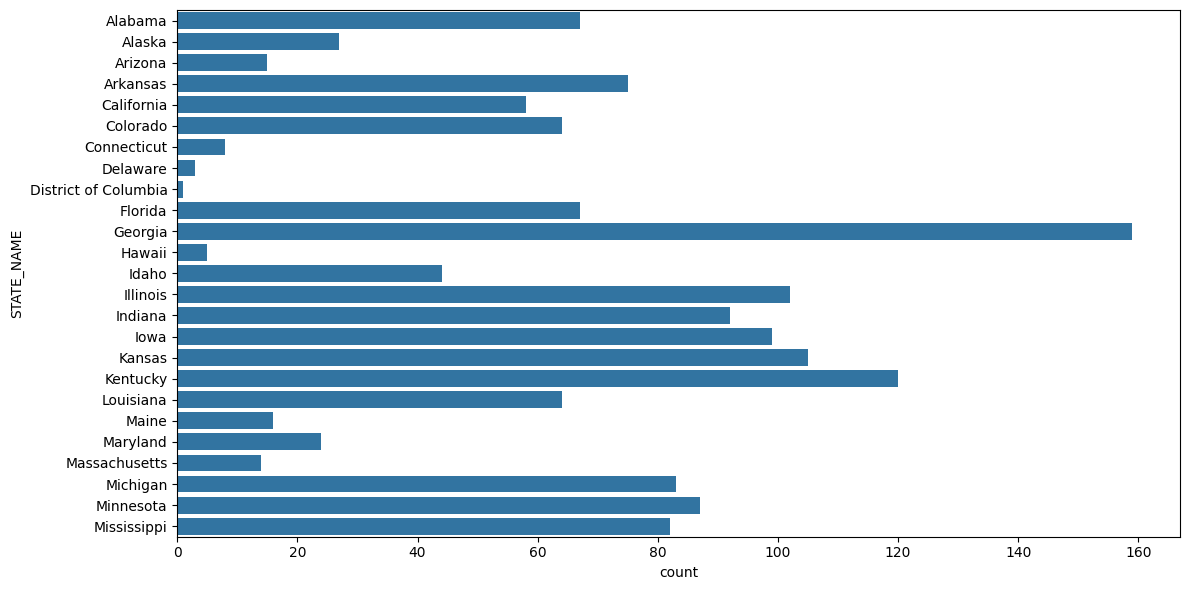

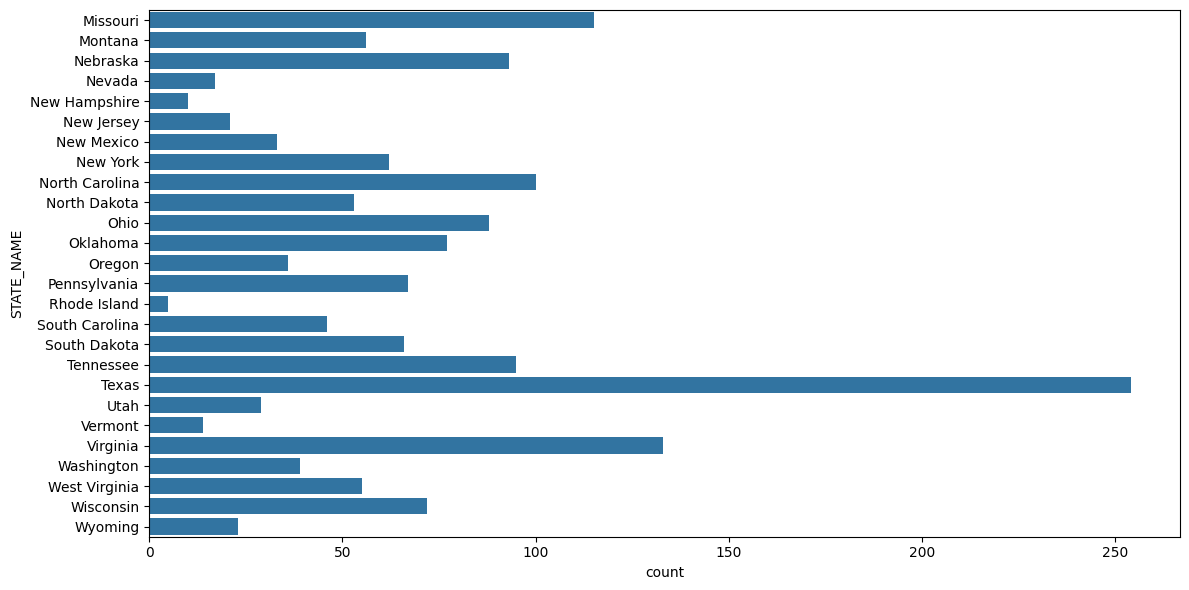

In [15]:
# Lista de todos los estados
states = df['STATE_NAME'].unique()

# Dividir en dos mitades 
mid = len(states) // 2
states_part1 = states[:mid]
states_part2 = states[mid:]

# Graficar la primera parte por orden alfabetico
plt.figure(figsize=(12, 6))
sns.countplot(y='STATE_NAME', data=df[df['STATE_NAME'].isin(states_part1)])
plt.tight_layout()

# Graficar la segunda parte por orden alfabetico
plt.figure(figsize=(12, 6))
sns.countplot(y='STATE_NAME', data=df[df['STATE_NAME'].isin(states_part2)])
plt.tight_layout()


#### Análisis de Variables Univariantes Numéricas

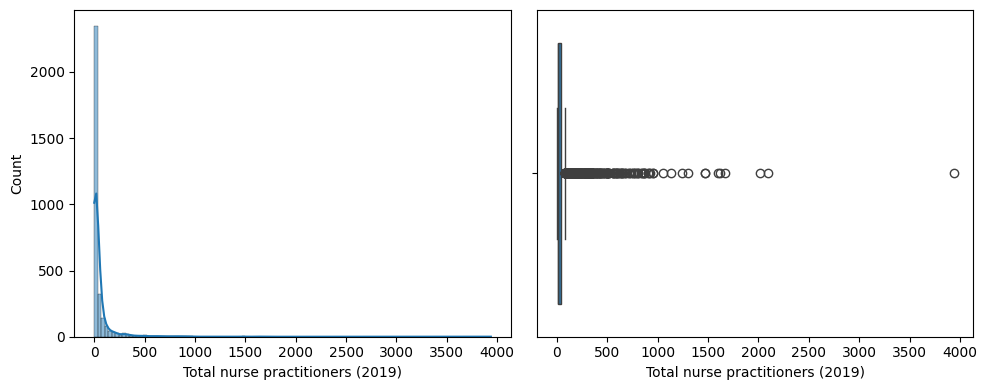

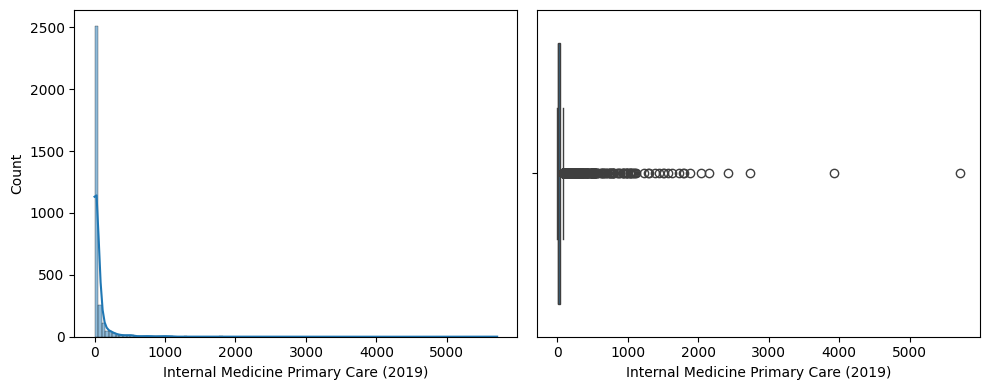

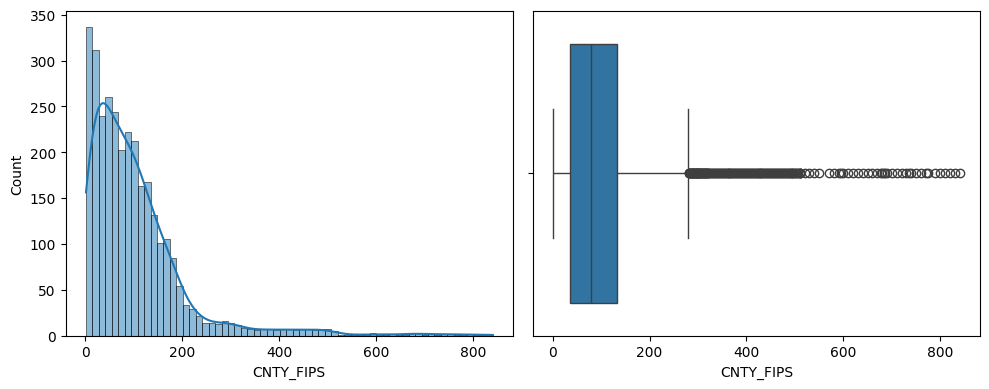

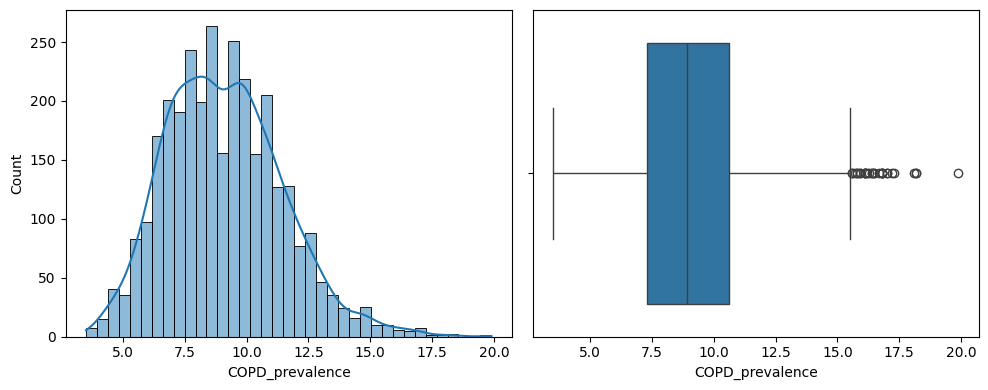

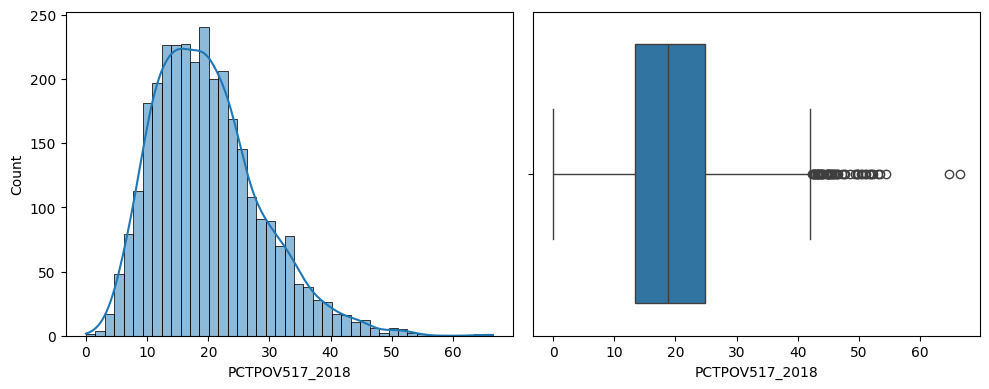

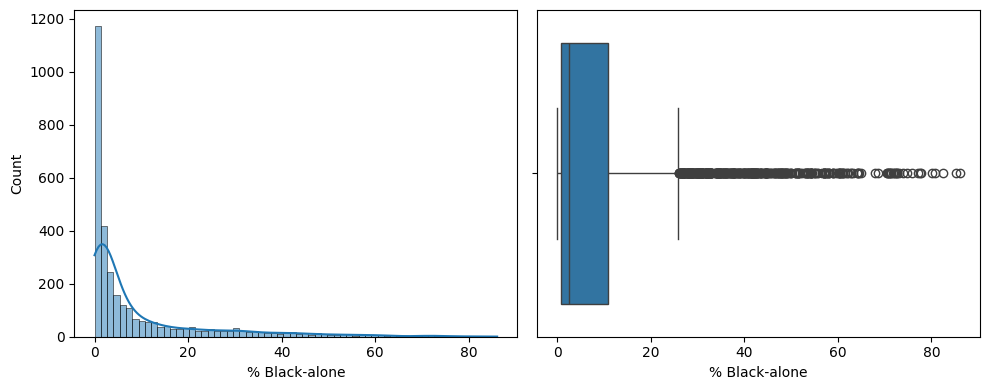

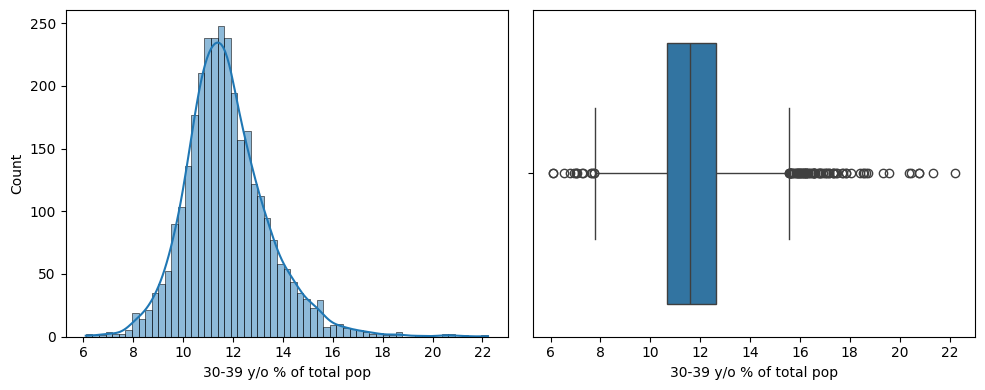

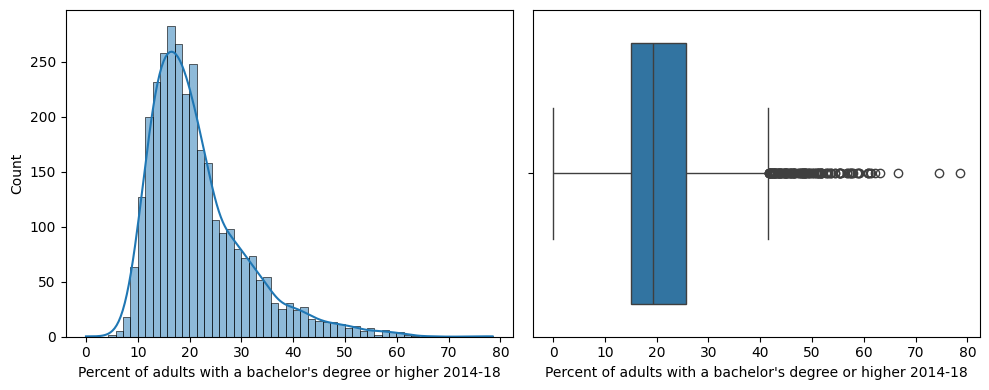

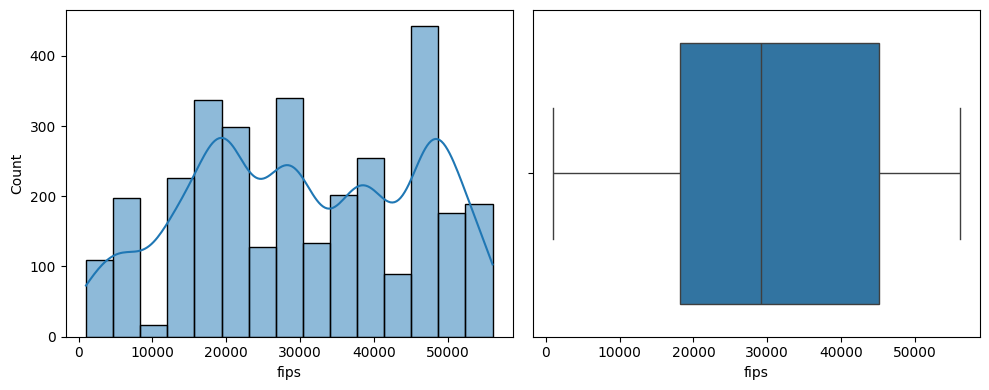

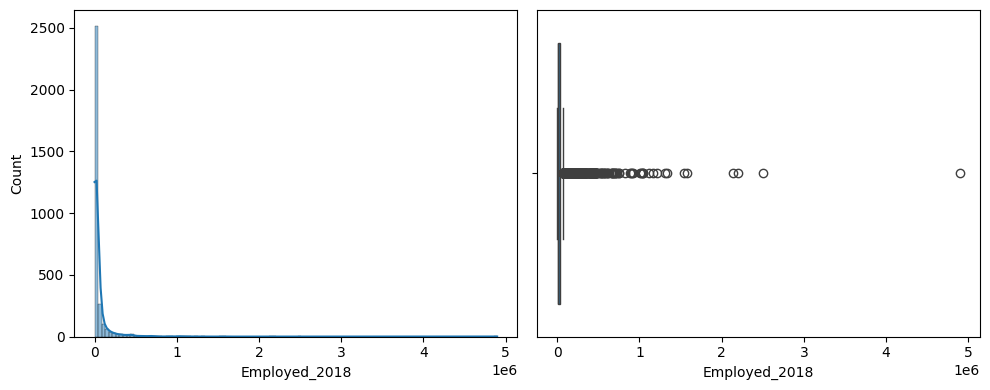

In [16]:
cols_numericas = [col for col in df.columns if col != 'STATE_NAME']  # Guardamos en una variables todas las columnas numéricas
random_cols = random.sample(cols_numericas, 10)  # Graficamos 10 variables numéricas aleatorias, ya que son muchas para visualizarlas todas

for col in random_cols:
    plt.figure(figsize=(10, 4)) 

    plt.subplot(1, 2, 1) 
    sns.histplot(data=df, x=col, kde=True)

    plt.subplot(1, 2, 2)  
    sns.boxplot(data=df, x=col)

    plt.tight_layout()

#### Análisis de Variables Multivariante (numerico-numerico)

In [17]:
cols_numericas_sin_target = [col for col in df.columns if col != 'STATE_NAME' and col != 'Heart disease_prevalence']
# Calculamos las 10 variables predictoras que tienen mayor correlacion con el target
correlaciones = df[cols_numericas_sin_target].corrwith(df['Heart disease_prevalence']).abs()
top_10_corr = correlaciones.sort_values(ascending=False).head(10)
top_10_corr_list = top_10_corr.index.tolist()
top_10_corr_list

['CKD_prevalence',
 'COPD_prevalence',
 'diabetes_prevalence',
 'anycondition_prevalence',
 'CI90LBINC_2018',
 'MEDHHINC_2018',
 'Median_Household_Income_2018',
 'CI90UBINC_2018',
 "Percent of adults with a bachelor's degree or higher 2014-18",
 'R_death_2018']

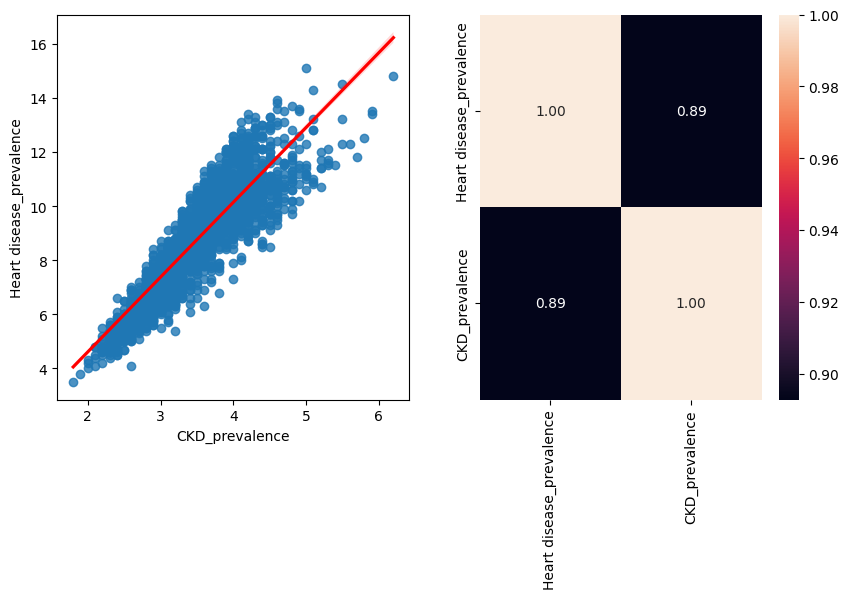

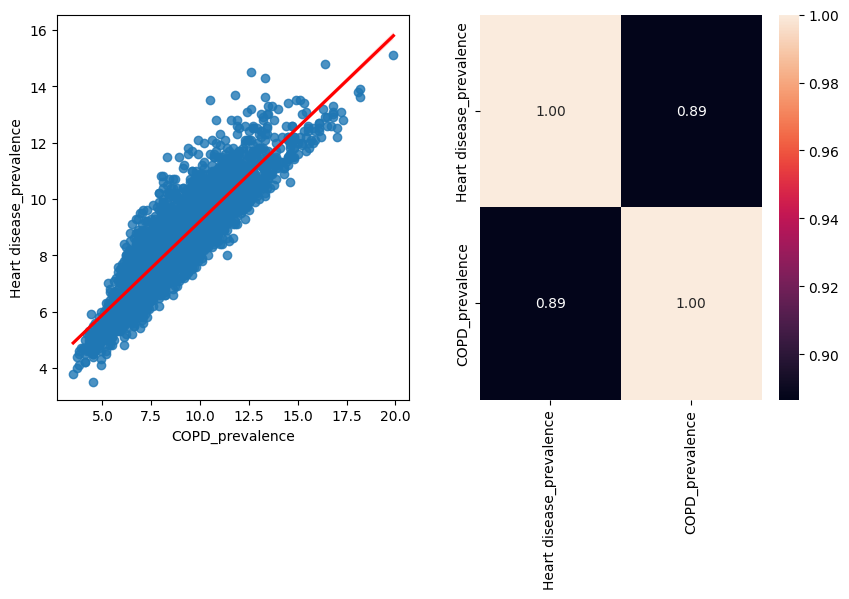

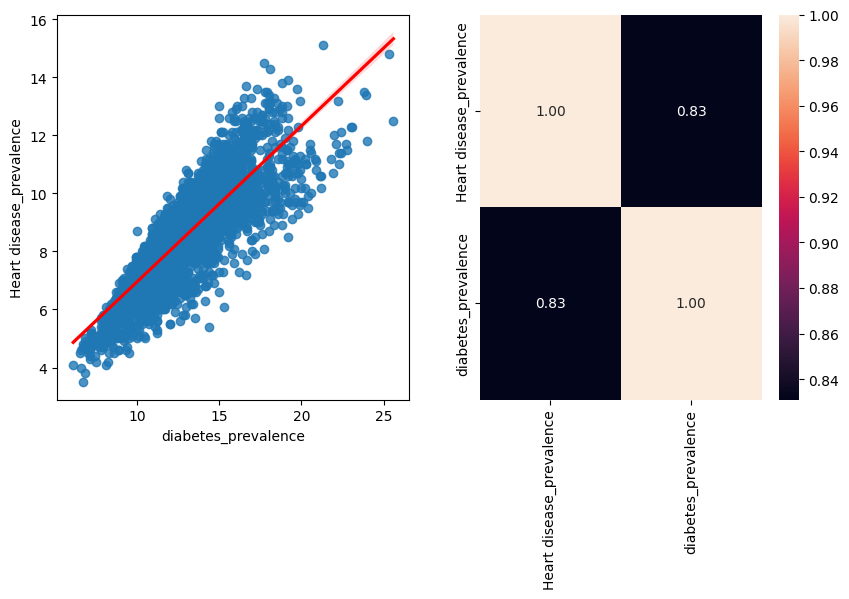

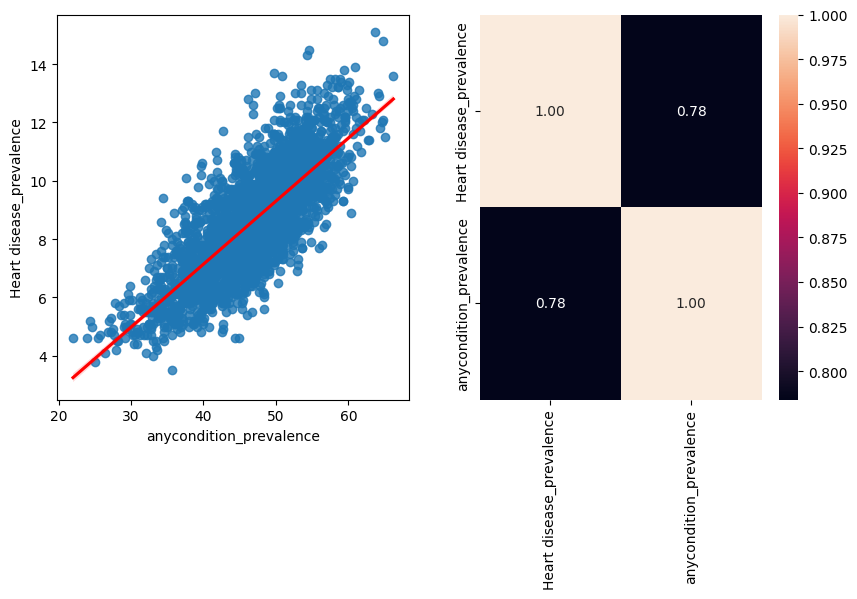

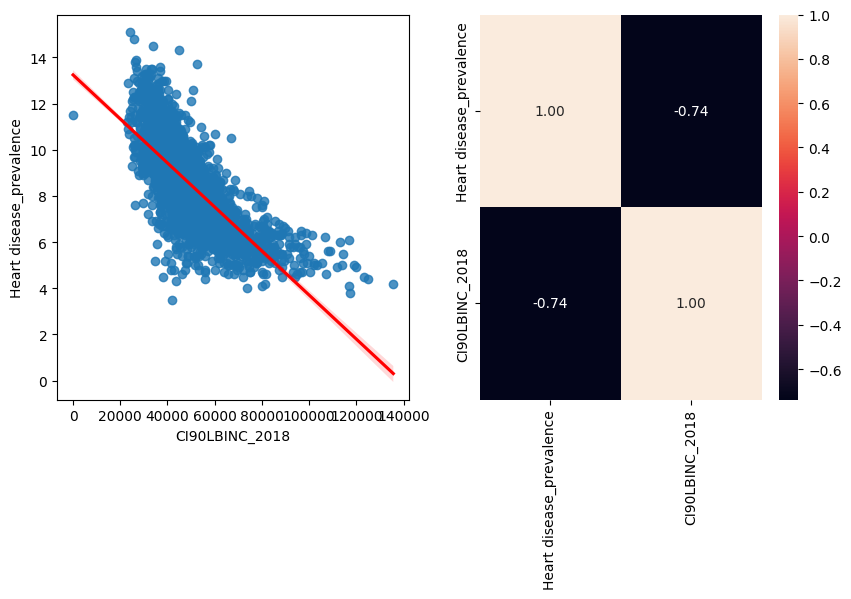

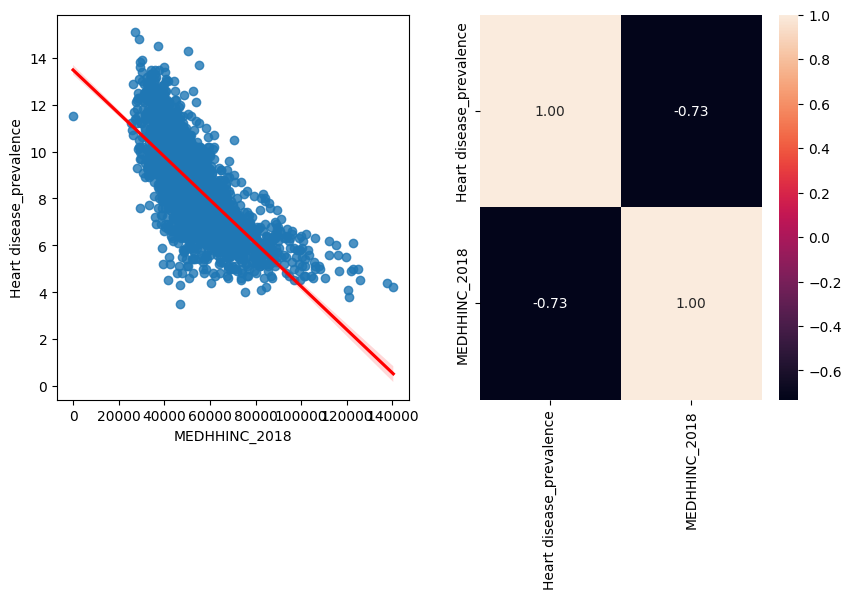

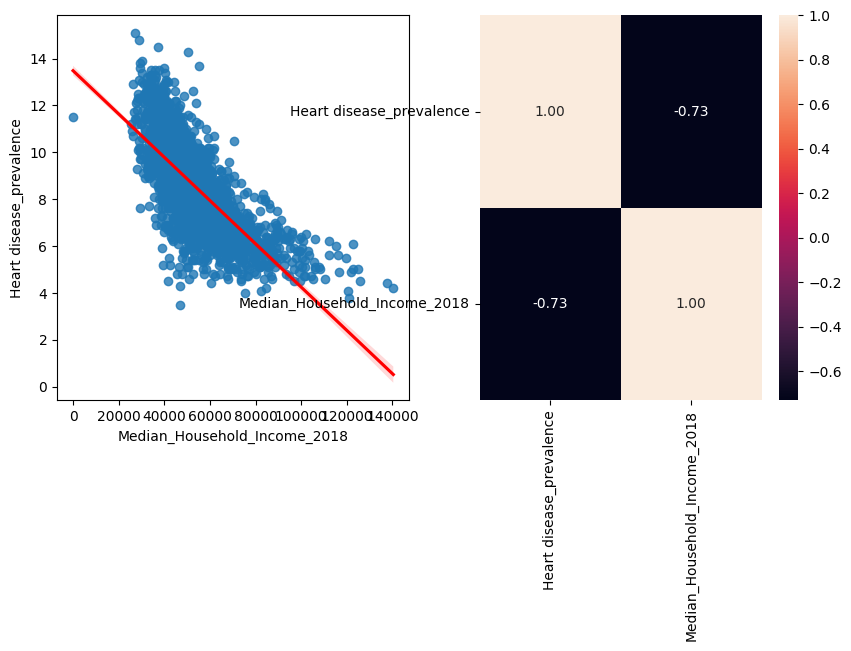

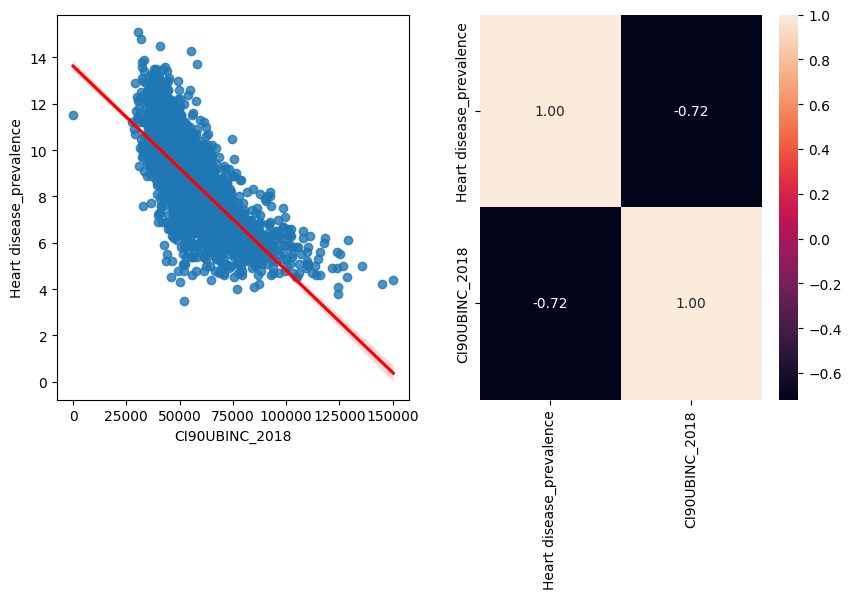

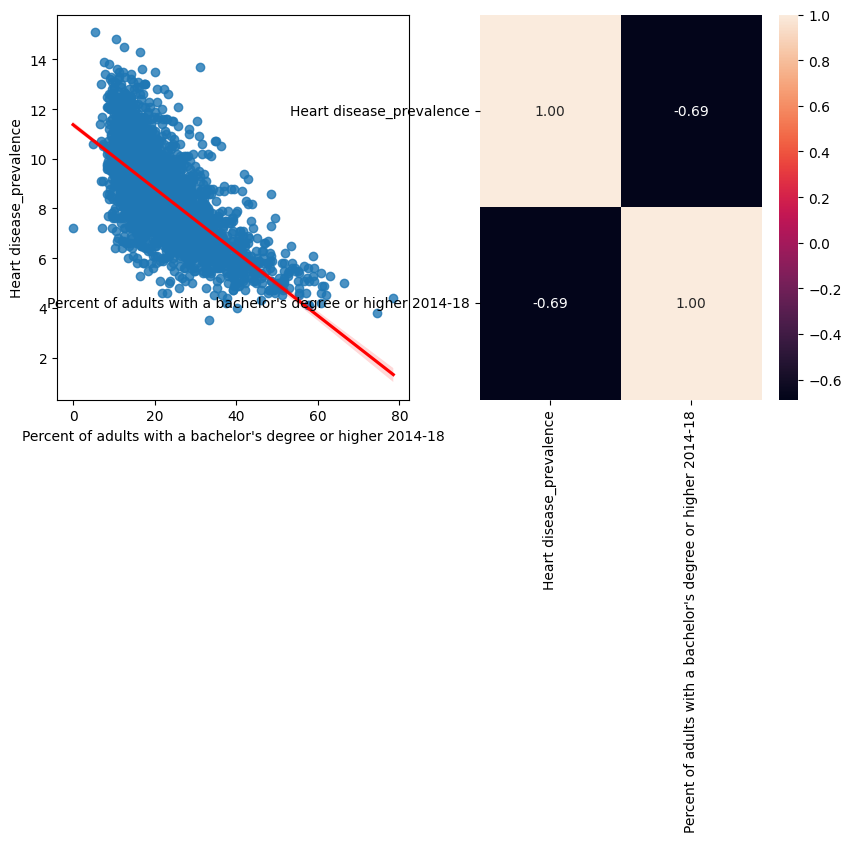

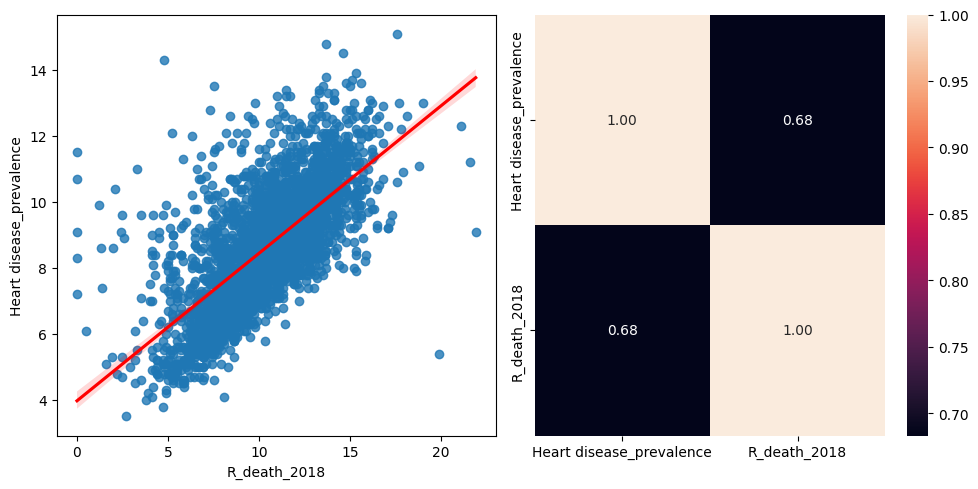

In [18]:
for col in top_10_corr_list:
    plt.figure(figsize=(10, 5)) 

    plt.subplot(1, 2, 1) 
    sns.regplot(data=df, x=col, y='Heart disease_prevalence', line_kws={'color': 'red'})

    plt.subplot(1, 2, 2)  
    sns.heatmap(df[['Heart disease_prevalence', col]].corr(), annot=True, fmt='.2f')

plt.tight_layout()

#### Análisis numérico-categórico (completo)

<Axes: >

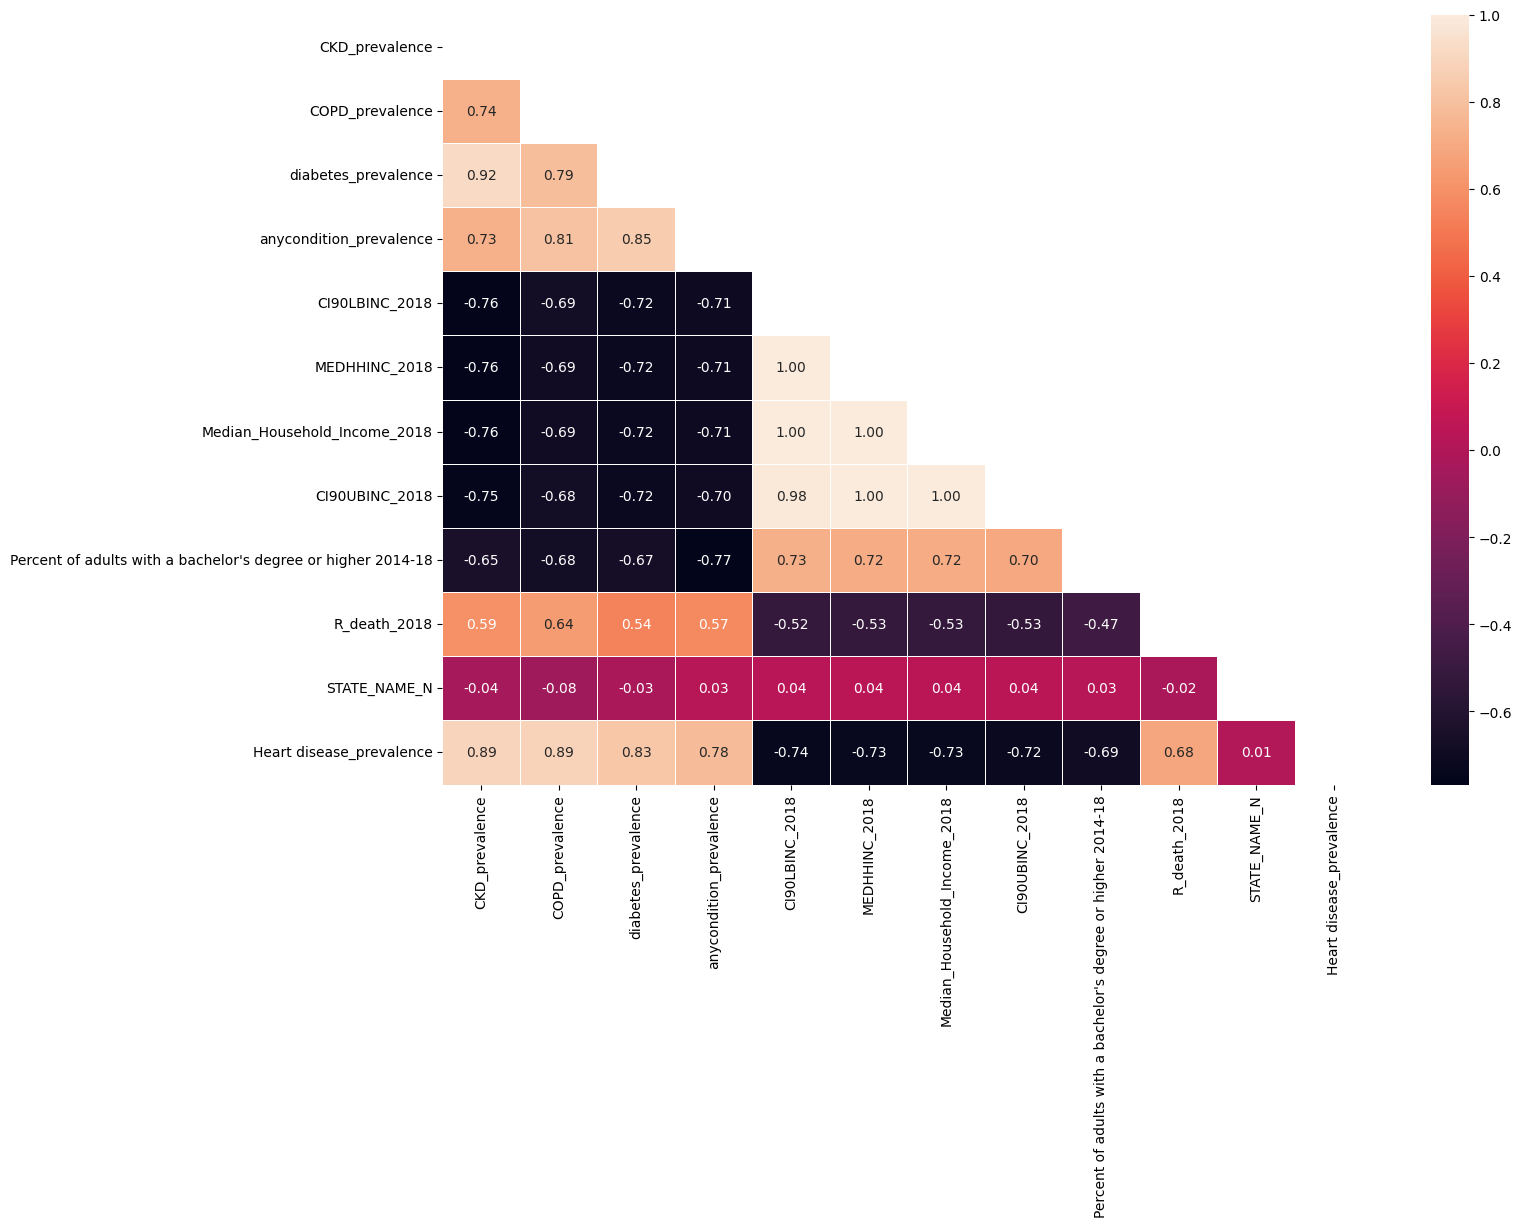

In [19]:
# Creo la columna numérica para la unica variable categórica y la añado junto al target a la lista 'top_10_corr_list', lo guardamos en una nueva lista 'num_var_best'
df['STATE_NAME_N'] = pd.factorize(df['STATE_NAME'])[0]
num_var_best = top_10_corr_list + ['STATE_NAME_N', 'Heart disease_prevalence']

corr = df[num_var_best].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(15, 10))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt='.2f')

> ## Observaciones:
>
> - En el gráfico podemos observar las 10 variables predictoras con mayor correlación con el target 
> - También tenemos la correlación de la única variable predictora categórica (`STATE NAME`) con el target, como podemos ver no hay ninguna relación directa entre ellas (0,01)

### Ingeniería de características

#### Análisis de outliers

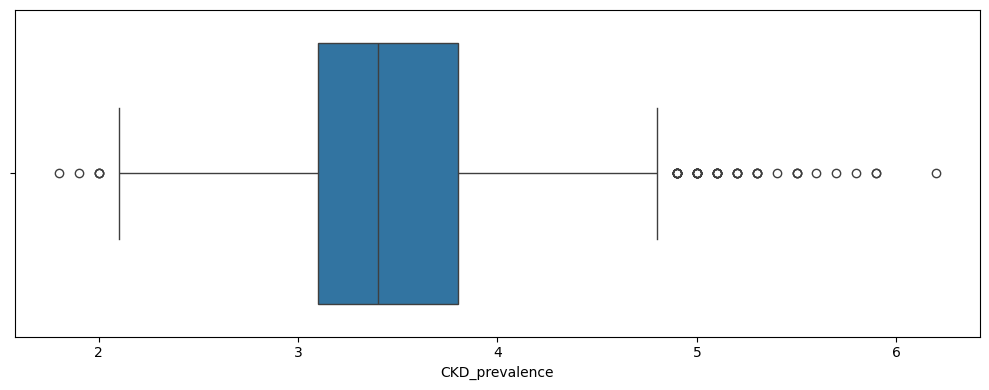

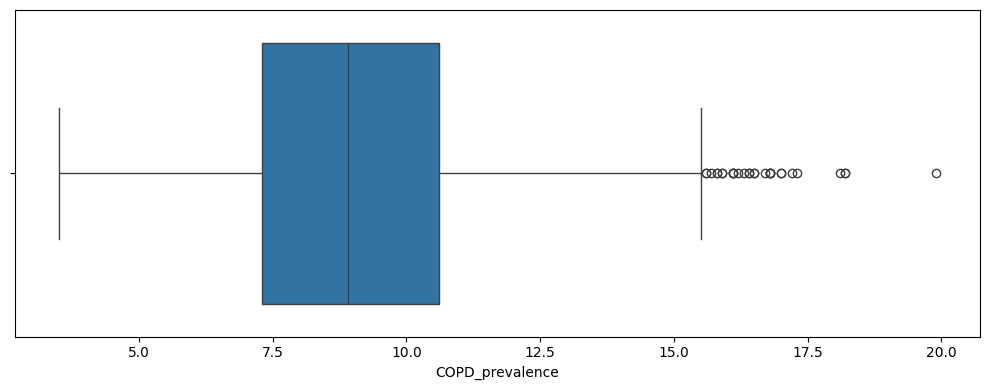

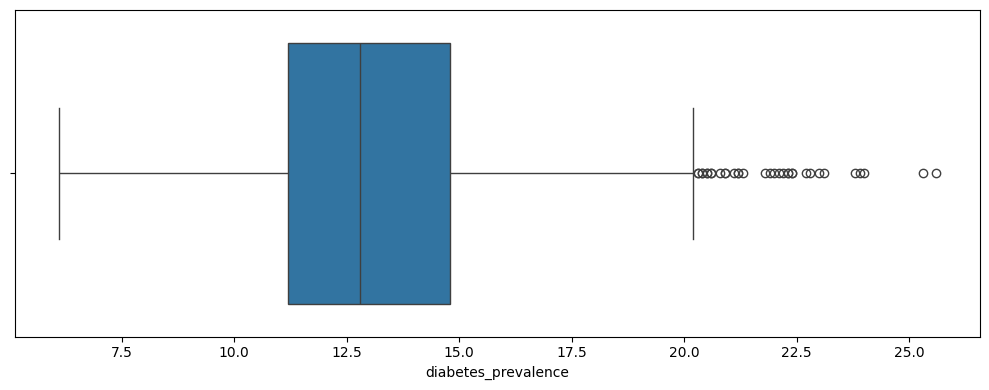

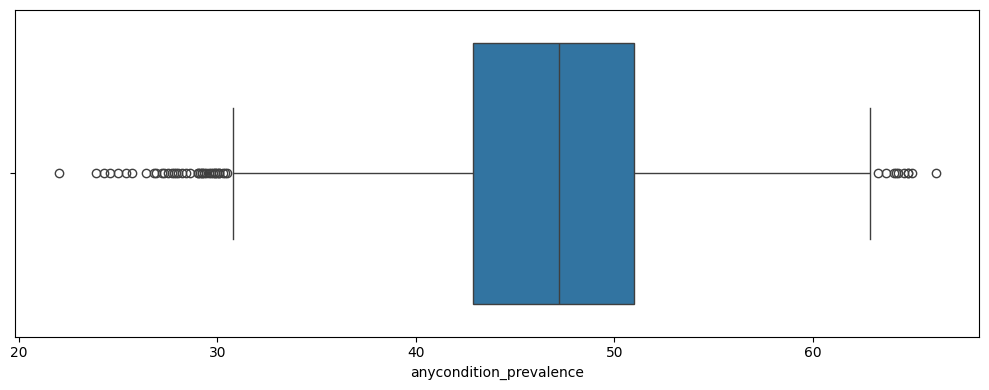

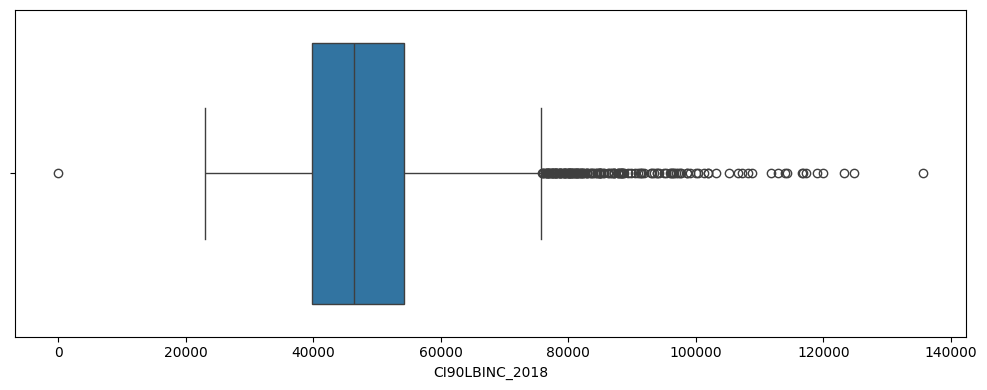

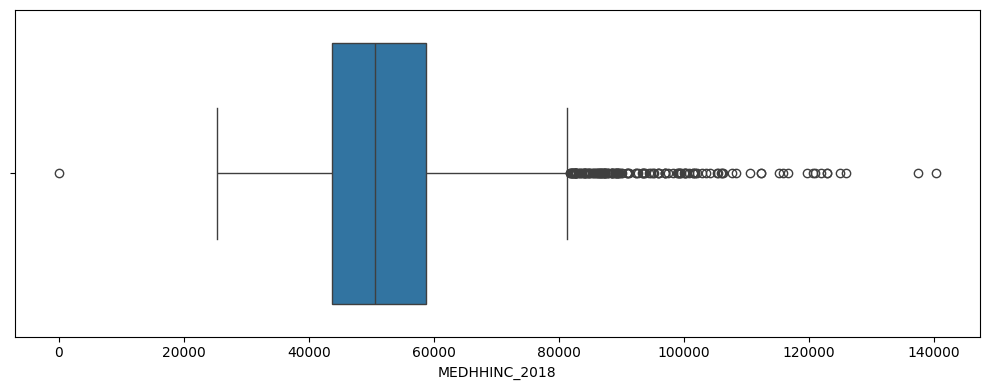

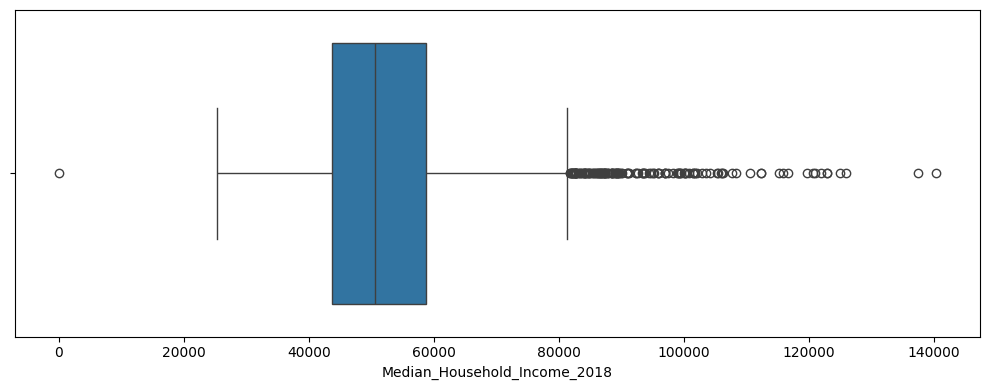

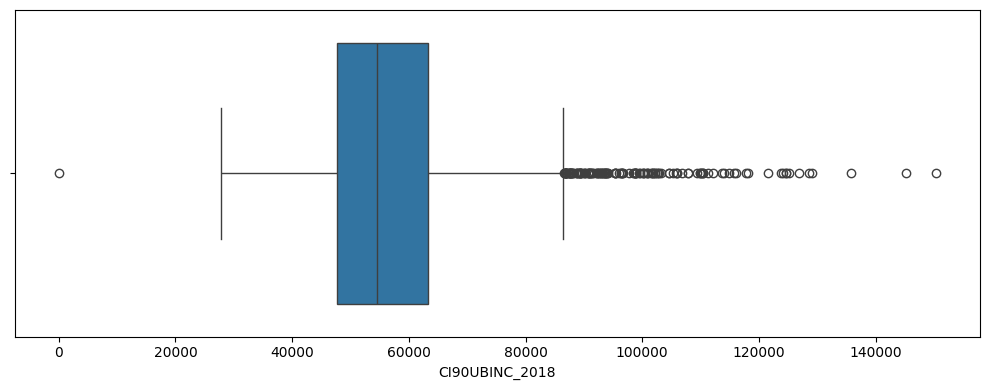

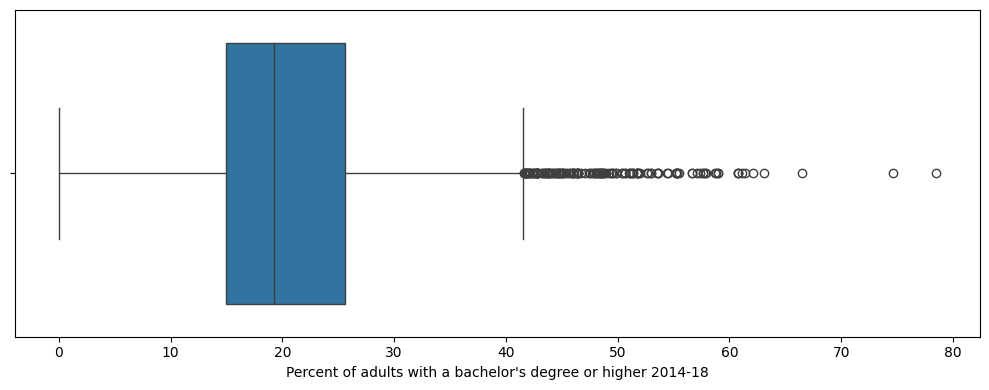

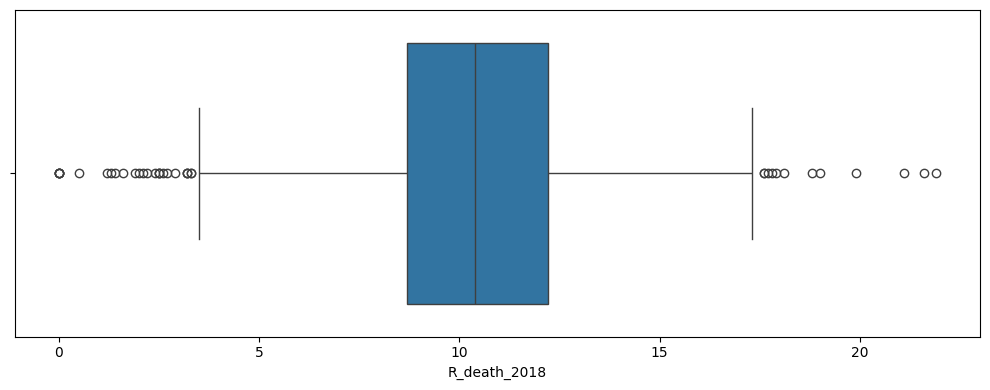

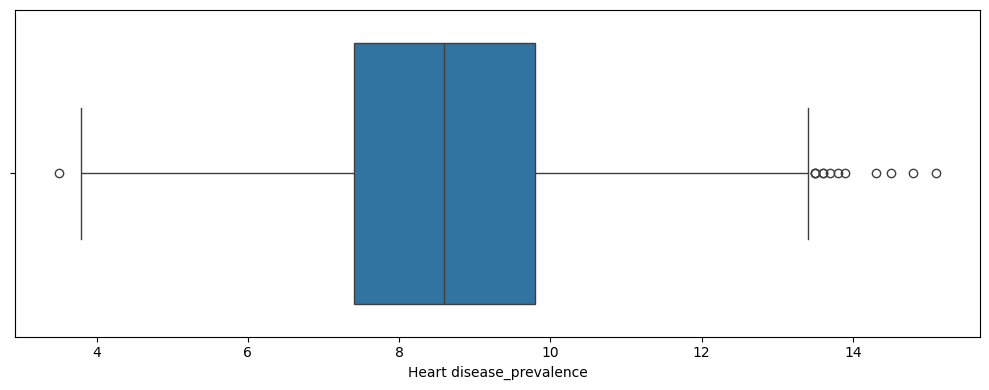

In [20]:
# Eliminamos la variable STATE_NAME_N ya que hemos visto que no tiene nada de relacion con el target
num_var_best.remove('STATE_NAME_N')

for col in num_var_best:
    plt.figure(figsize=(10, 4)) 
    
    sns.boxplot(data=df, x=col)

    plt.tight_layout()


> ## Observaciones:
>
> - Todas las variables con correlaciones altas con el target tienen outliers
> - De momento vamos a conservar todos los outliers

#### Análisis de valores faltantes

In [21]:
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

> ## Observaciones:
> - No existen valores nulos

#### Inferencia de nuevas características

In [22]:
df.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,Heart disease_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code,STATE_NAME_N
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Autauga,1001,55601,12.206615,13.735364,12.370281,12.749771,13.636445,13.917016,10.478229,7.284042,...,1,42438,47.6,35.8,7.9,8.6,12.9,3.1,3,0
Baldwin,1003,218022,11.355276,12.344167,10.814964,11.564429,12.539102,13.753658,13.728890,9.602701,...,3,170912,40.2,29.7,7.8,8.6,12.0,3.2,4,0
Barbour,1005,24881,10.980266,11.896628,13.134520,12.865239,12.354809,13.174712,12.362847,9.018930,...,5,19689,57.5,40.7,11.0,12.1,19.7,4.5,6,0
Bibb,1007,22400,10.964286,11.589286,13.522321,13.897321,13.562500,13.906250,11.361607,7.691964,...,7,17813,51.6,38.7,8.6,10.0,14.1,3.3,2,0
Blount,1009,57840,12.266598,13.087828,11.656293,11.901798,12.921853,13.561549,12.041840,8.525242,...,9,44448,46.3,34.0,9.2,10.5,13.5,3.4,2,0


> ## Observaciones 
> 
> - No encontramos relación para crear una variable a partir de la fusion de varias

### Split (Segundo Enfoque)

In [23]:
X = df.drop('Heart disease_prevalence', axis= 1)
y = df['Heart disease_prevalence']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)
X_train

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code,STATE_NAME_N
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Osage,29151,13714,12.016917,13.934665,11.674202,11.258568,12.308590,14.671139,11.973166,7.583491,...,29,151,10543,43.2,31.4,8.8,10.8,2.9,4,25
Wise,48497,68305,13.083962,14.082424,11.555523,12.715028,12.634507,14.425005,11.455970,7.053656,...,48,497,51386,50.9,39.5,8.3,12.3,3.1,2,43
Livingston,36051,63227,9.114777,13.495817,15.623072,10.756481,11.063312,14.818037,13.105161,7.566388,...,36,51,52072,42.5,35.4,8.6,10.7,3.0,2,32
Calhoun,28013,14436,11.907731,13.563314,11.450540,11.041840,12.371848,13.791909,13.071488,7.931560,...,28,13,11060,57.5,38.1,11.7,16.7,4.1,6,24
Saline,29195,22895,12.094344,13.968115,13.430880,11.657567,11.107229,12.810657,12.015724,7.975541,...,29,195,17775,50.2,36.8,10.1,12.8,3.4,5,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Mobile,1097,413757,12.907818,12.945038,13.869977,12.820085,11.746508,13.018994,11.894421,7.174501,...,1,97,317046,48.9,36.9,9.1,14.4,3.5,3,0
Switzerland,18155,10717,13.417934,13.483251,10.627974,11.626388,12.382197,14.528319,12.242232,7.772698,...,18,155,8072,52.3,40.4,12.2,14.9,3.5,6,14
Jefferson,36045,111755,14.597110,11.769496,19.365576,14.248132,10.029976,11.119860,9.590622,5.941569,...,36,45,84957,45.3,37.1,7.9,9.6,2.7,4,32


### Scaling - Escalado Mínimo-Máximo (variables numéricas)

In [24]:
min_max_scaler = MinMaxScaler()
# Ajustamos solo con los datos de entrenamiento
min_max_scaler.fit(X_train[cols_numericas_sin_target])

X_train_scal = min_max_scaler.transform(X_train[cols_numericas_sin_target])
X_train_scal = pd.DataFrame(X_train_scal, index=X_train.index, columns=cols_numericas_sin_target)

X_test_scal = min_max_scaler.transform(X_test[cols_numericas_sin_target])
X_test_scal = pd.DataFrame(X_test_scal, index=X_test.index, columns=cols_numericas_sin_target)

X_train_scal.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,Percent of Population Aged 60+,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Osage,0.511409,0.001348,0.471979,0.597942,0.310730,0.320213,0.576054,0.617959,0.357925,0.184835,...,0.280822,0.509091,0.178784,0.001321,0.479638,0.466859,0.314815,0.241026,0.250000,0.6
Wise,0.862873,0.006751,0.513889,0.604283,0.307572,0.410495,0.595455,0.601700,0.336220,0.166645,...,0.253425,0.854545,0.591180,0.006480,0.653846,0.700288,0.283951,0.317949,0.295455,0.2
Livingston,0.636763,0.006248,0.357994,0.579111,0.415837,0.289090,0.501925,0.627663,0.405432,0.184248,...,0.296233,0.636364,0.059595,0.006567,0.463801,0.582133,0.302469,0.235897,0.272727,0.2
Calhoun,0.490735,0.001420,0.467691,0.582007,0.304777,0.306778,0.579820,0.559879,0.404019,0.196784,...,0.337329,0.490909,0.014303,0.001386,0.803167,0.659942,0.493827,0.543590,0.522727,1.0
Saline,0.512208,0.002257,0.475021,0.599377,0.357488,0.344945,0.504539,0.495059,0.359711,0.198294,...,0.301370,0.509091,0.231228,0.002234,0.638009,0.622478,0.395062,0.343590,0.363636,0.8


In [25]:
# Guardamos el scaler utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/lineal-regression-reg-min_max_scaler.pkl', 'wb') as file:
    pickle.dump(min_max_scaler, file)

### Seleccción de Características

In [26]:
# Selecciona las k mejores características, da igual el k que pongamos que no vamos a tener overfiting, el EDA realizado ha sido muy eficiente porque se han eliminado muchas variables redundates
selection_model = SelectKBest(f_regression, k=68)
selection_model.fit(X_train_scal, y_train)
bool_variables = selection_model.get_support()

X_train_sel = selection_model.transform(X_train_scal)
X_train_sel = pd.DataFrame(X_train_sel, index=X_train_scal.index, columns=X_train_scal.columns.values[bool_variables])

X_test_sel = selection_model.transform(X_test_scal)
X_test_sel = pd.DataFrame(X_test_sel, index=X_test_scal.index, columns=X_test_scal.columns.values[bool_variables])

X_test_sel.head()

,fips,TOT_POP,0-9 y/o % of total pop,10-19 y/o % of total pop,20-29 y/o % of total pop,30-39 y/o % of total pop,40-49 y/o % of total pop,50-59 y/o % of total pop,60-69 y/o % of total pop,70-79 y/o % of total pop,...,Percent of Population Aged 60+,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,Obesity_prevalence,COPD_prevalence,diabetes_prevalence,CKD_prevalence,Urban_rural_code
COUNTY_NAME,,,,,,,,,,,,,,,,,,,,,
Durham,0.655149,0.031335,0.477817,0.509226,0.428968,0.646095,0.603191,0.428480,0.292039,0.112769,...,0.195205,0.654545,0.073897,0.031684,0.337104,0.432277,0.141975,0.235897,0.227273,0.4
Fairfield,0.800051,0.002208,0.385539,0.487679,0.304759,0.249890,0.516433,0.689429,0.541659,0.250601,...,0.378425,0.800000,0.045292,0.002276,0.647059,0.746398,0.401235,0.671795,0.613636,0.4
Saline,0.293656,0.002357,0.466432,0.510847,0.307297,0.347575,0.547296,0.564827,0.410010,0.226494,...,0.347603,0.290909,0.195471,0.002354,0.610860,0.593660,0.456790,0.358974,0.454545,1.0
Monona,0.329409,0.000850,0.450733,0.542375,0.268039,0.235841,0.452414,0.536284,0.447792,0.261901,...,0.450342,0.327273,0.157330,0.000843,0.583710,0.605187,0.302469,0.333333,0.431818,1.0
Emporia,0.919156,0.000498,0.372745,0.599958,0.338363,0.342544,0.525694,0.537584,0.352889,0.218790,...,0.291096,0.909091,0.707986,0.000499,0.773756,0.780980,0.493827,0.728205,0.750000,1.0


In [27]:
# Guardamos el selection_model utilizando Pickle (que nos permite guardar objetos de Python)
with open('../models/lineal-regression-reg-selection-model.pkl', 'wb') as file:
    pickle.dump(selection_model, file)

In [28]:
#Guardamos los datos de entrenamiento y prueba
with open('../data/processed/03-X_train_sel.pkl', 'wb') as f:
    pickle.dump(X_train_sel, f)
   
with open('../data/processed/03-X_test_sel.pkl', 'wb') as f:
    pickle.dump(X_test_sel, f)

#Guardamos los datos de entrenamiento y prueba
with open('../data/processed/03-y_train.pkl', 'wb') as f:
    pickle.dump(y_train, f)
   
with open('../data/processed/03-y_test.pkl', 'wb') as f:
    pickle.dump(y_test, f)

> ## Conclusiones
>
> EDA terminado, ya tenemos nuetro conjuntos de datos de entrenamientos y de prueba para empezar a construir el modelo:
> - `X_train_sel`, `X_test_sel` ,`y_train` , `y_test`